**Description:**

This section implements a quantitative framework to grade each Reverse LBP event. We measure four key aspects of a successful launch and normalize them onto a standard **0-100 Score**.

To prevent negative scores, all formulas use a "floor" logic: `Score = max(0, Formula)`. This means extreme failures result in a 0, not a negative number.

#### 1. Bot & Frontrunning Resistance

* **The Goal:** Prevent snipers from stealing value in the first few blocks.
* **The Formula:** $$Score = 100 - (2 \times \% \text{SniperVolume})$$

* **The Logic (Why $\times 2$?):**
We define **50% Bot Volume** as a total failure. If half the liquidity is taken by bots ($50 \times 2 = 100$), the score drops to **0**.

#### 2. Fair Value Discovery

* **The Goal:** The price should stabilize after the LBP ends, finding a true "fair market value."
* **The Formula:** $$Score = 100 - (200 \times \text{PriceDeviation})$$

* **The Logic (Why $\times 200$?):**
We define a **50% Price Crash** (or Pump) as a total failure. If the price moves 50% ($0.50$) immediately after the event, the score hits **0** ($0.50 \times 200 = 100$ penalty).

#### 3. Market Stability

* **The Goal:** Sell tokens smoothly without causing chaotic volatility per trade.
* **The Formula:** $$Score = 100 - (1000 \times \text{Volatility})$$

* **The Logic (Why $\times 1000$?):**
Volatility is usually a tiny number (e.g., 0.01). We define **10% Volatility** per trade as "Chaos." If volatility hits 0.10, the score drops to **0** ($0.10 \times 1000 = 100$ penalty).

#### 4. Cost Efficiency

* **The Goal:** Provide better execution prices (lower slippage) than a standard sale.
* **The Formula:** $$Score = 100 - (2000 \times \text{AvgImpact})$$

* **The Logic (Why $\times 2000$?):**
We define **5% Average Slippage** as unusable liquidity. If the average user loses 5% ($0.05$) on a trade, the pool is inefficient and the score hits **0** ($0.05 \times 2000 = 100$ penalty).

#### 5. Execution Differential (vs. External Market)

* **The Goal:** Ensure the protocol is buying back tokens cheaper than the open market (CEX/DEX) price.
* **The Formula:** $$Score = 50 + (100 \times \% \text{DiscountObtained})$$

* **The Logic (Why Start at 50?):**
This metric is centered around zero.
* **0% Discount (Parity):** Score = 50 (Neutral execution).
* **+5% Discount:** Score = 50 + (100 * 0.05) = 55 (Good execution).
* **-5% Premium:** Score = 50 + (100 * -0.05) = 45 (Bad execution).
* **-50% Premium:** Score = 0 (Total Failure).

#### 6. Markout Analysis (1H Inventory PnL)

* **The Goal:** Avoid "toxic flow" (buying just before the price dumps). A positive markout means the buy was timed well (buying the dip).
* **The Formula:** $$Score = 50 + (200 \times \% \text{MarkoutPnL})$$

* **The Logic (Why $\times 200$?):**
* **0% Markout:** Score = 50 (Price stayed flat after buy).
* **+2.5% Markout:** Score = 50 + (200 * 0.025) = 55 (We bought the bottom).
* **-25% Markout:** Score = 0 (We bought the exact top before a crash).

#### 7. Source Toxicity (Flow Quality)

* **The Goal:** Minimize buying from MEV bots (toxic/arbitrage) and maximize buying from Aggregators (organic/user).
* **The Formula:** $$Score = 100 - (100 \times \% \text{MEVVolume})$$

* **The Logic (Why $\times 100$?):**
We define **100% MEV Volume** as a fully captured/toxic pool.
* **0% MEV:** Score = 100 (Pure organic flow).
* **30% MEV:** Score = 70 (Acceptable leakage).
* **100% MEV:** Score = 0 (The pool existed only to feed arbitrage bots).

# Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from datetime import timedelta

# Constants

In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
V1V2_POOLS_FILE = "../../../media/dune_web_downloads/rLBPs/dev_rLBPs_Final_cleaned_pools_addresses.csv"
V1V2_TRADES_FILE = "../../../media/dune_web_downloads/rLBPs/dev_rLBPs_Final_trades.csv"
V1V2_MARKET_FILE = "../../../media/dune_web_downloads/rLBPs/dev_rLBPs_Final_market_values.csv"

# Known Decimals
DECIMALS = {
    'USDC': 6, 'USDT': 6, 'DAI': 18, 'WETH': 18, 'BAL': 18,
    'MIM': 18, 'FRAX': 18, 'LUSD': 18
}

# Analysis

## Spot price

### Theorical spot price curve (without swaps) in USD

Initializing Data...
 > Fetching ETH-USD history from 2020-01-01 to 2023-01-01...

Generating Theoretical Curve for: WETH_LBP_0x4693


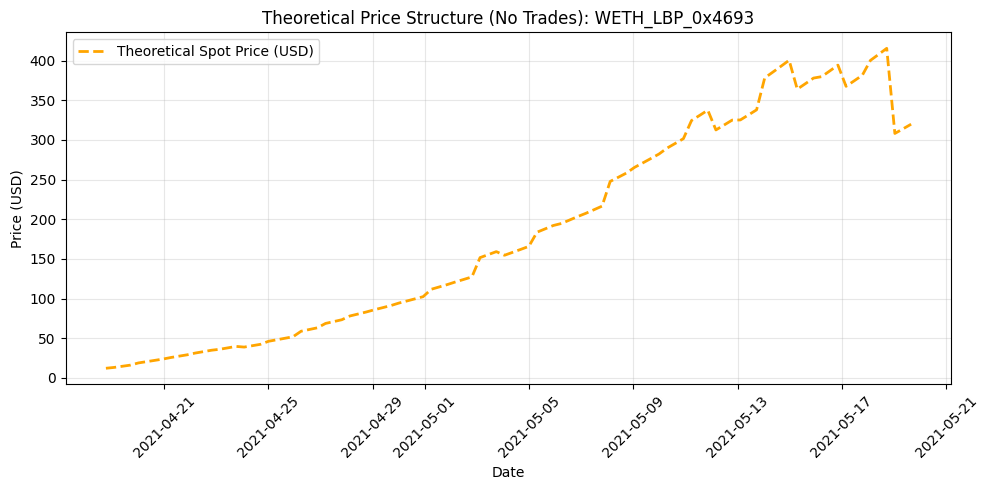


Generating Theoretical Curve for: WETH_LBP_0xa4a8


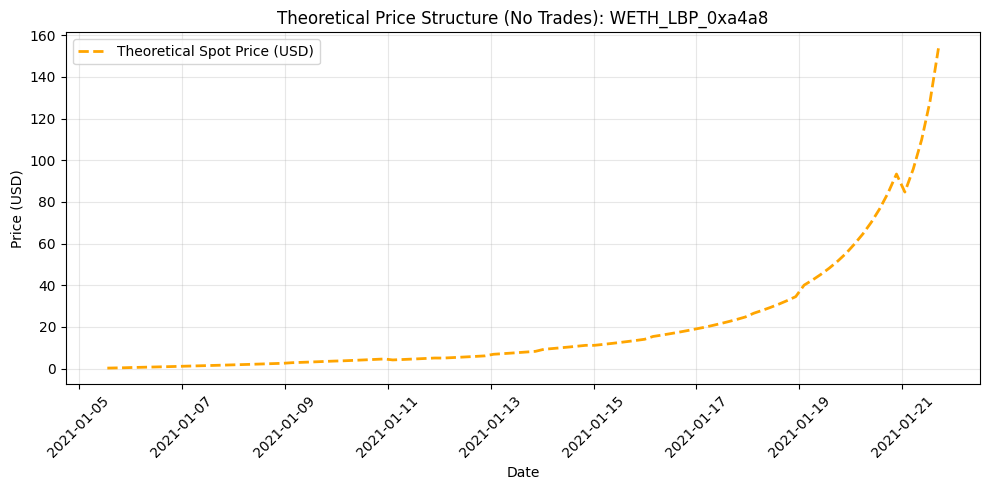


Generating Theoretical Curve for: DAI_LBP_0x174c


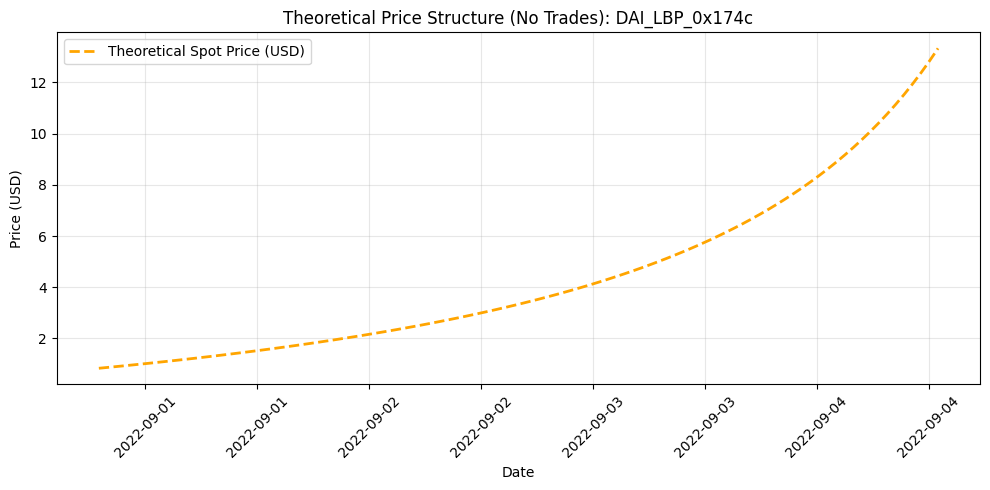


Generating Theoretical Curve for: DAI_LBP_0x177f


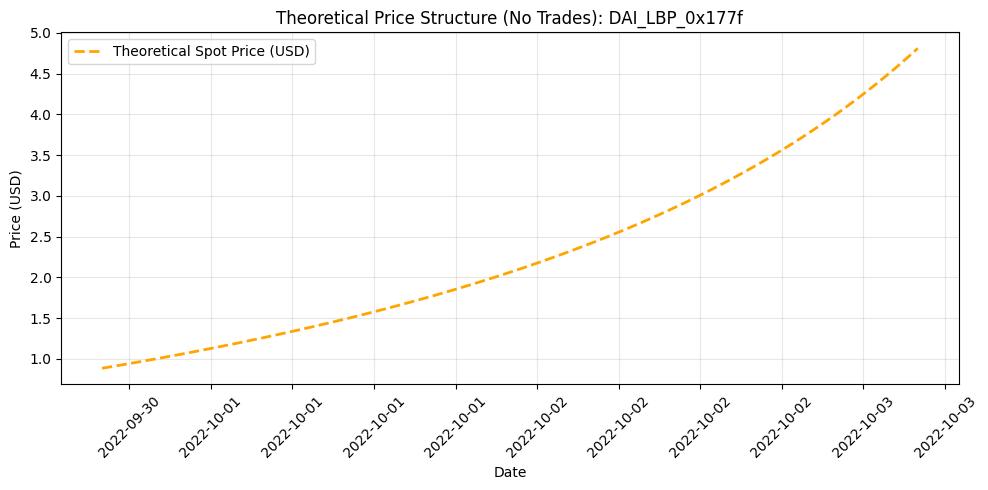


Generating Theoretical Curve for: DAI_LBP_0x3e87


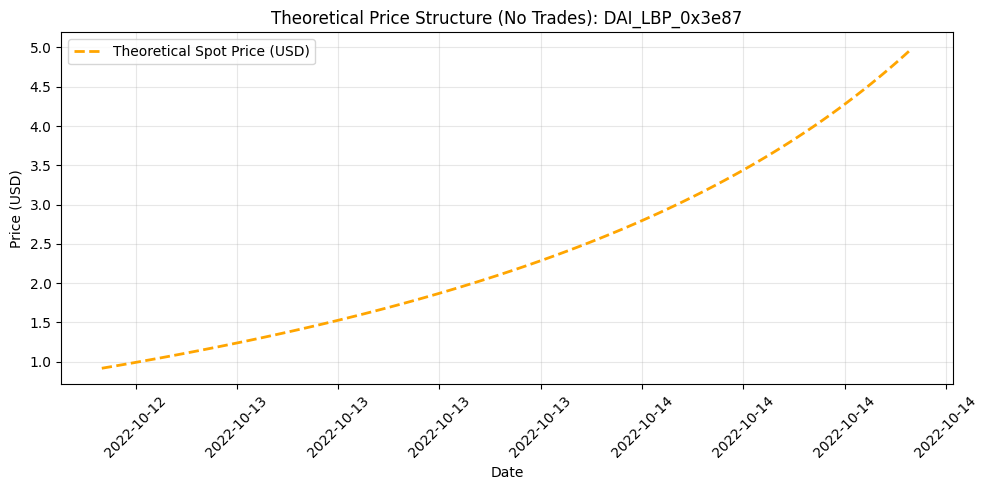


Generating Theoretical Curve for: DAI_LBP_0x6f25


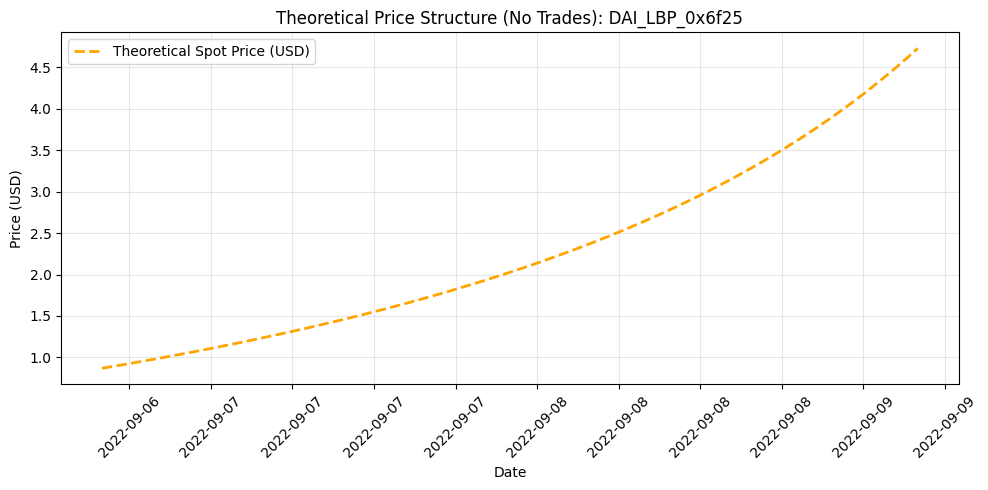


Generating Theoretical Curve for: DAI_LBP_0x8de0


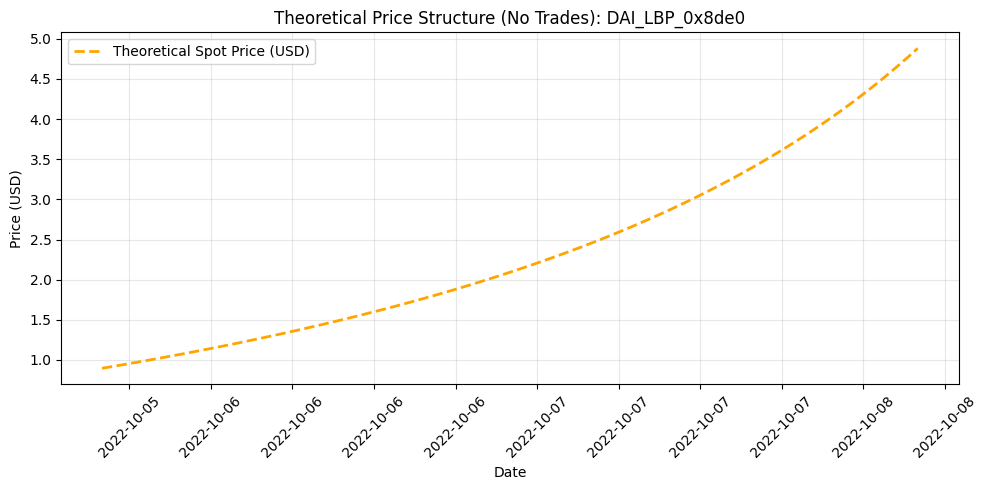


Generating Theoretical Curve for: FRAX_LBP_0xa47d


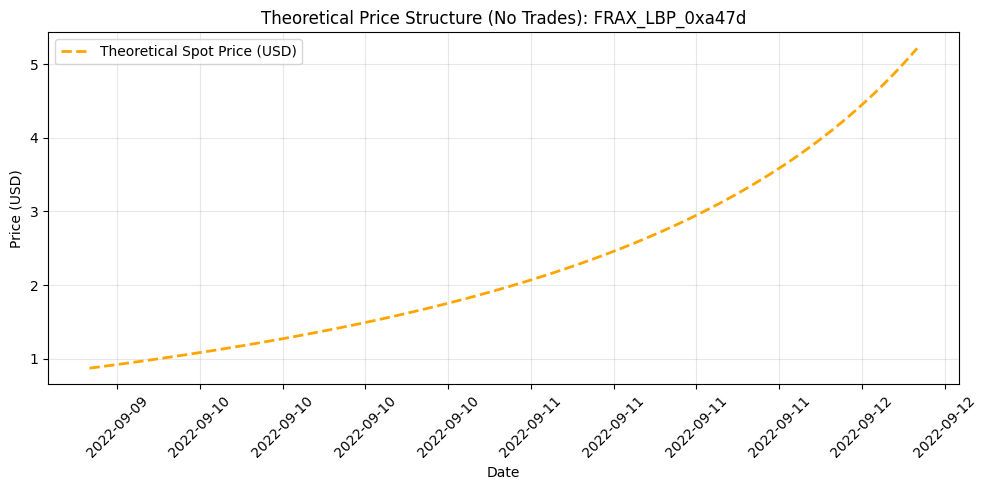


Generating Theoretical Curve for: DAI_LBP_0xa49b


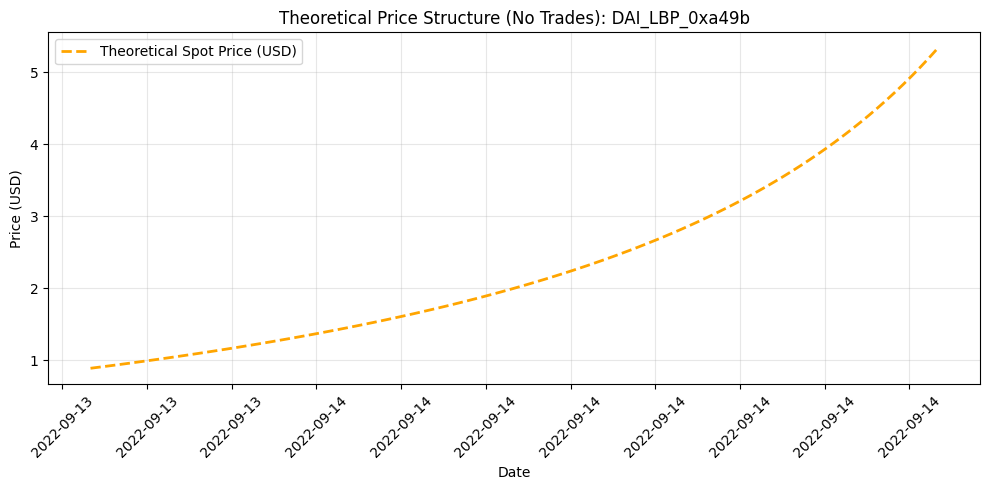


Generating Theoretical Curve for: DAI_LBP_0xbaed


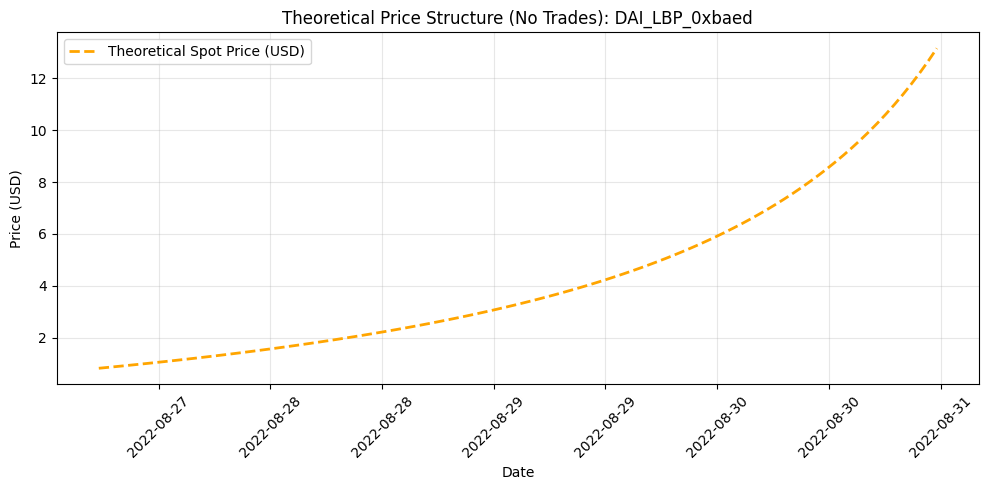


Generating Theoretical Curve for: DAI_LBP_0xd328


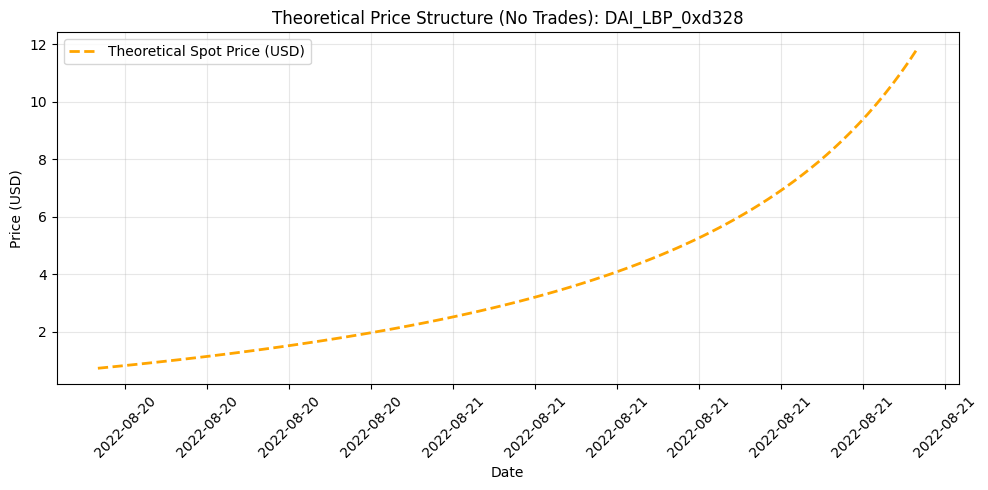


Generating Theoretical Curve for: DAI_LBP_0xe11b


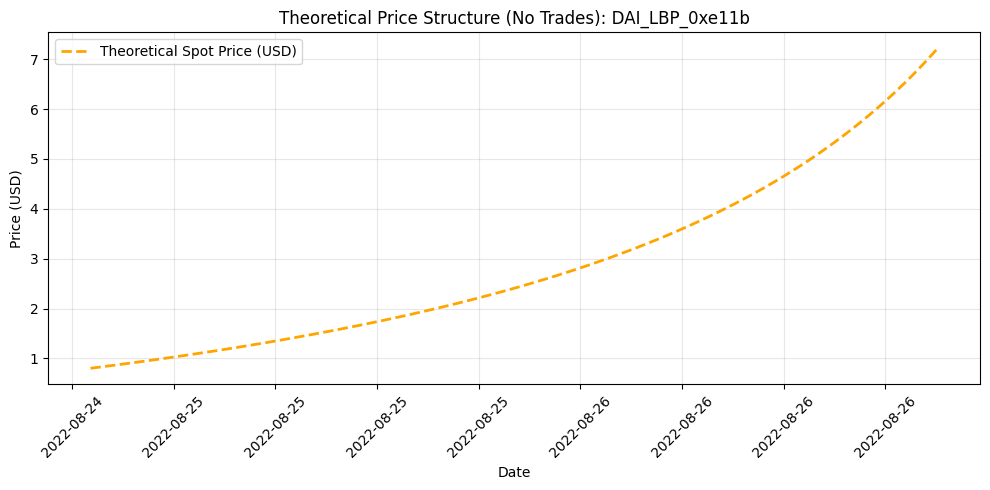


Generating Theoretical Curve for: DAI_LBP_0xf812


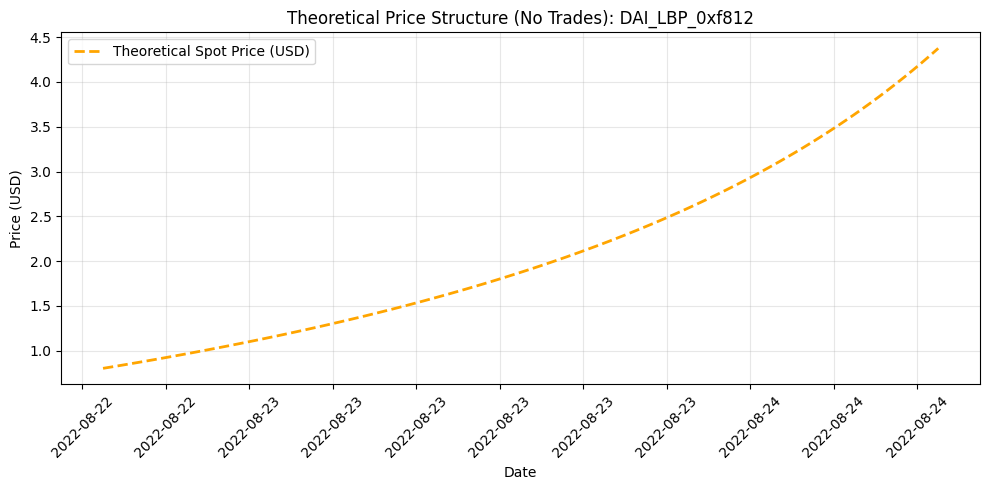


Generating Theoretical Curve for: DAI_LBP_0xf882


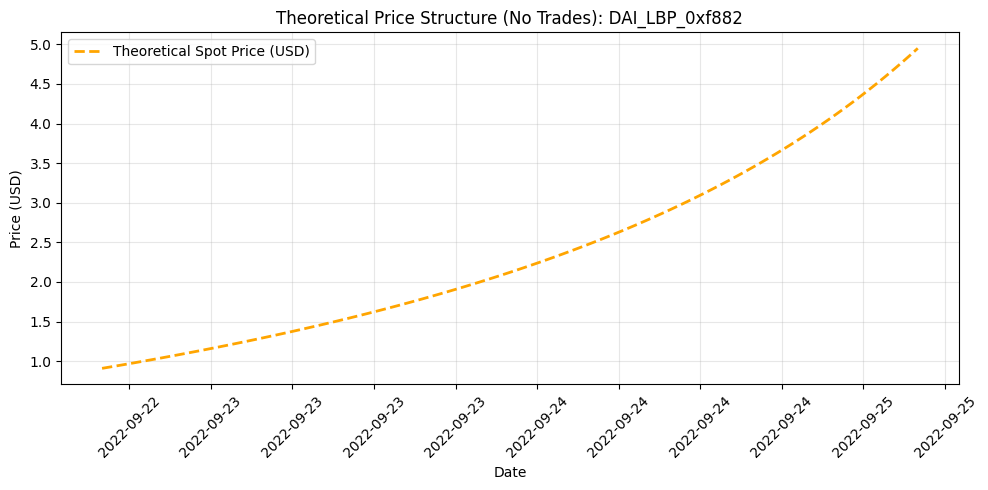

In [3]:
# ==========================================
# 1. HELPER: Fetch Historical ETH Price
# ==========================================
def fetch_usd_history_robust(symbol, start_date, end_date):
    """Fetches USD price history ensuring we cover the full window."""
    try:
        # We only need ETH history for WETH pools
        if symbol != 'WETH': return None
        
        print(f" > Fetching ETH-USD history from {start_date.date()} to {end_date.date()}...")
        
        # Add buffer to dates to ensure coverage
        s_str = (start_date - timedelta(days=5)).strftime('%Y-%m-%d')
        e_str = (end_date + timedelta(days=5)).strftime('%Y-%m-%d')
        
        data = yf.download("ETH-USD", start=s_str, end=e_str, progress=False)
        
        if data.empty: 
            print("   ! Error: YFinance returned no data.")
            return None
            
        # Handle MultiIndex if necessary
        if isinstance(data.columns, pd.MultiIndex):
            data = data['Close']
        else:
            data = data[['Close']]
            
        df = data.reset_index()
        df.columns = ['timestamp', 'price']
        df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None)
        
        return df.set_index('timestamp')['price']
    except Exception as e:
        print(f"   ! Exception fetching history: {e}")
        return None

# ==========================================
# 2. LOAD DATA
# ==========================================
# Assumes you have the file paths defined or loaded
# If not, uncomment the lines below and adjust paths
# V1V2_POOLS_FILE = 'dev_rLBPs_Final_cleaned_pools_addresses.csv'

df_pools = pd.read_csv(V1V2_POOLS_FILE)
df_pools['start_date'] = pd.to_datetime(df_pools['start_date'])
df_pools['end_date'] = pd.to_datetime(df_pools['end_date'])

# Pre-fetch ETH History for the entire range (2020-2023) to be safe
print("Initializing Data...")
eth_history = fetch_usd_history_robust('WETH', pd.to_datetime("2020-01-01"), pd.to_datetime("2023-01-01"))

# ==========================================
# 3. GENERATE THEORETICAL CURVES
# ==========================================
for _, pool in df_pools.iterrows():
    pname = f"{pool['collateral_symbol']}_LBP_{pool['pool_address'][:6]}"
    print(f"\nGenerating Theoretical Curve for: {pname}")

    # Initial Balances (Fixed for Theoretical Calculation)
    const_bal_col = pool['collateral_balance']
    const_bal_proj = pool['project_balance']
    
    # Weights
    w_col_start = pool['collateral_start_weight'] / 100.0
    w_col_end = pool['collateral_end_weight'] / 100.0
    
    # Generate Time Points (100 steps from Start to End)
    total_seconds = (pool['end_date'] - pool['start_date']).total_seconds()
    time_steps = np.linspace(0, total_seconds, 100)
    
    theoretical_curve = []
    
    for t in time_steps:
        # Calculate Timestamp
        curr_ts = pool['start_date'] + timedelta(seconds=t)
        
        # 1. Interpolate Weight (Linear)
        progress = t / total_seconds
        w_col_curr = w_col_start + (w_col_end - w_col_start) * progress
        w_proj_curr = 1.0 - w_col_curr
        
        # 2. Calculate Spot Price (Standard Balancer Formula)
        # Price = (Bal_Col / W_Col) / (Bal_Proj / W_Proj)
        # Note: We use CONSTANT balances here
        if w_col_curr <= 0 or w_proj_curr <= 0:
            raw_price = 0
        else:
            raw_price = (const_bal_col / w_col_curr) / (const_bal_proj / w_proj_curr)
            
        # 3. Convert to USD
        usd_price = raw_price
        
        # Only convert if Collateral is WETH and we have history
        if pool['collateral_symbol'] == 'WETH' and eth_history is not None:
            try:
                # Find nearest ETH price for this specific timestamp
                day_key = curr_ts.replace(hour=0, minute=0, second=0, microsecond=0)
                
                # Fast lookup
                if day_key in eth_history.index:
                    eth_price = eth_history.loc[day_key]
                else:
                    # Fallback to nearest
                    idx = eth_history.index.get_indexer([day_key], method='nearest')[0]
                    eth_price = eth_history.iloc[idx]
                
                usd_price = raw_price * eth_price
            except Exception:
                pass # Fail silently to raw_price if date issue
        
        theoretical_curve.append({'date': curr_ts, 'price': usd_price})

    # ==========================================
    # 4. PLOT
    # ==========================================
    if theoretical_curve:
        df_viz = pd.DataFrame(theoretical_curve)
        
        plt.figure(figsize=(10, 5))
        plt.plot(df_viz['date'], df_viz['price'], label='Theoretical Spot Price (USD)', color='orange', linestyle='--', linewidth=2)
        
        plt.title(f"Theoretical Price Structure (No Trades): {pname}")
        plt.ylabel("Price (USD)")
        plt.xlabel("Date")
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

### Empirical spot price


Processing EMPIRICAL Price for: ICHI (WETH LBP)...
   > Pool Address: 0x46935b2489d1468a580ccc3ccba11d1eb7737199
   > Duration: ~30.9 days
   > Total Trades: 101 | Valid for Plot: 101
   > Saved chart to: rLBP_ICHI_WETH_0x4693_2021-04-18.png


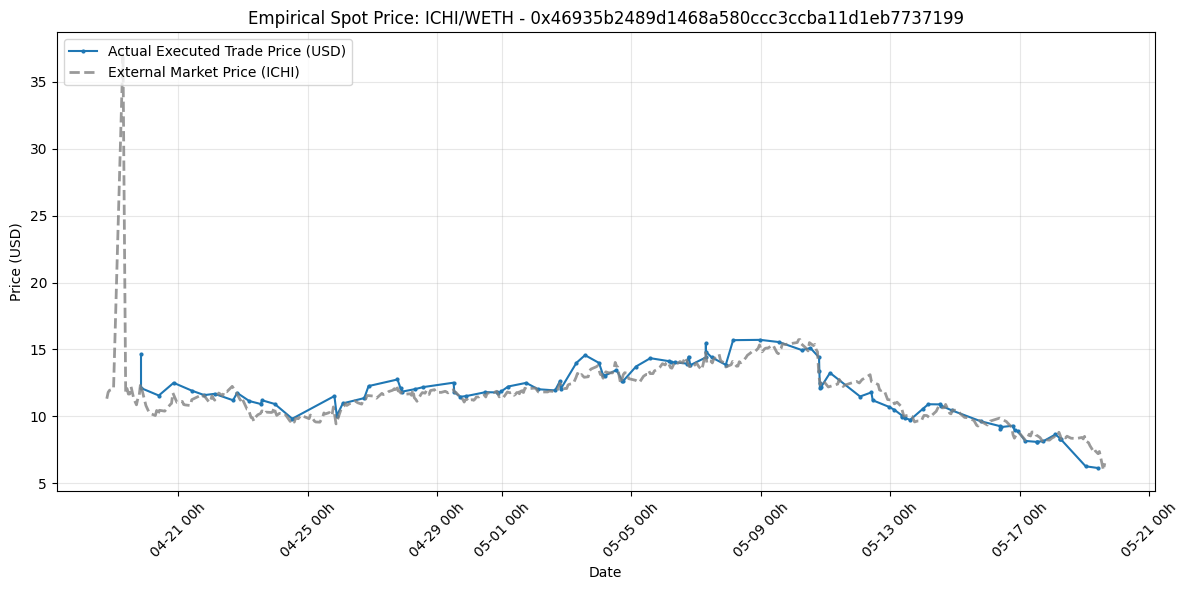


Processing EMPIRICAL Price for: IDLE (WETH LBP)...
   > Pool Address: 0xa4a8a79295fa8d0da16b557a9dcad290ff3da321
   > Duration: ~16.1 days
   > Total Trades: 1148 | Valid for Plot: 1148
   > Saved chart to: rLBP_IDLE_WETH_0xa4a8_2021-01-05.png


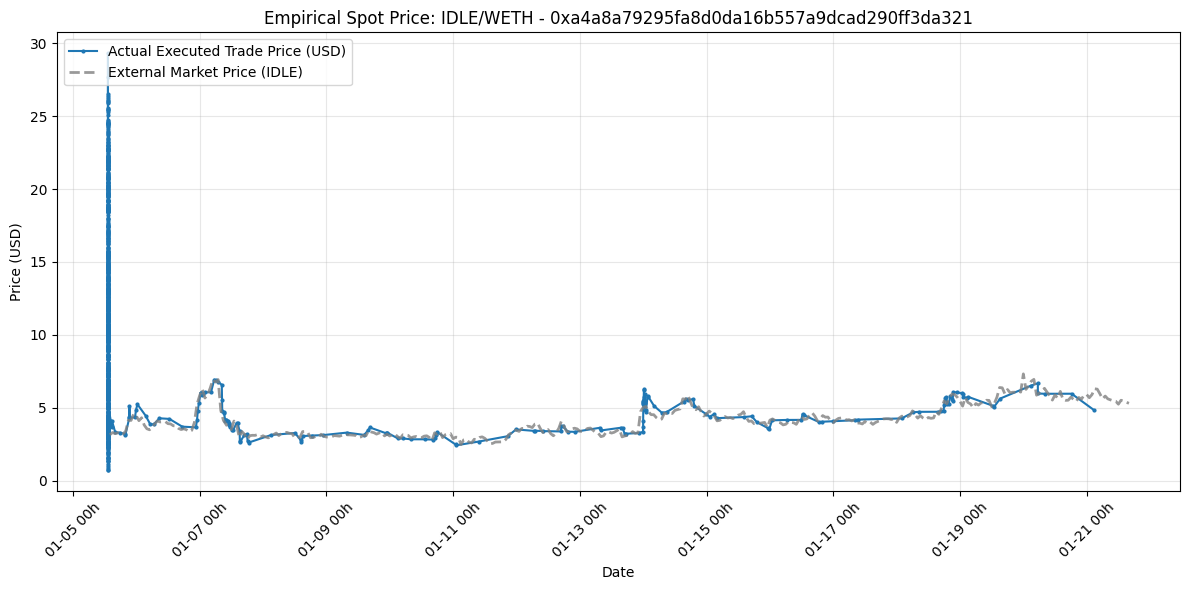


Processing EMPIRICAL Price for: TEMPLE (DAI LBP)...
   > Pool Address: 0x174cfa15a24f3fc49fc2bc66b5e6046e549557c9
   > Duration: ~3.8 days
   > Total Trades: 225 | Valid for Plot: 225
   > Saved chart to: rLBP_TEMPLE_DAI_0x174c_2022-08-31.png


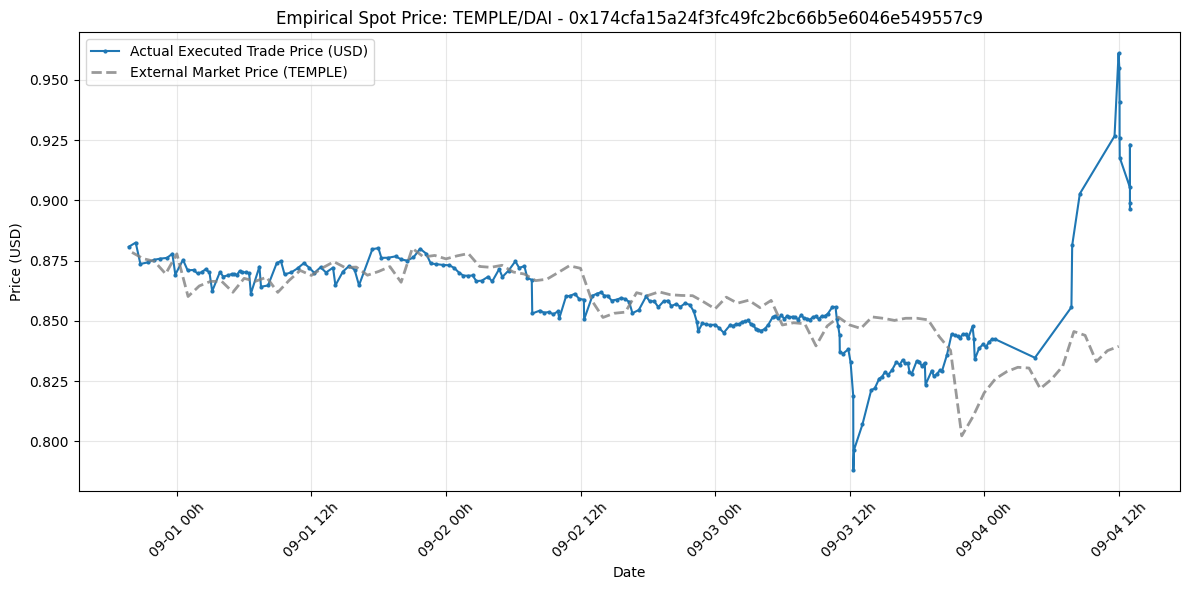


Processing EMPIRICAL Price for: TEMPLE (DAI LBP)...
   > Pool Address: 0x177f00928ebc2b222af50a7595af7e7ef0d86a7b
   > Duration: ~2.5 days
   > Total Trades: 517 | Valid for Plot: 517
   > Saved chart to: rLBP_TEMPLE_DAI_0x177f_2022-09-30.png


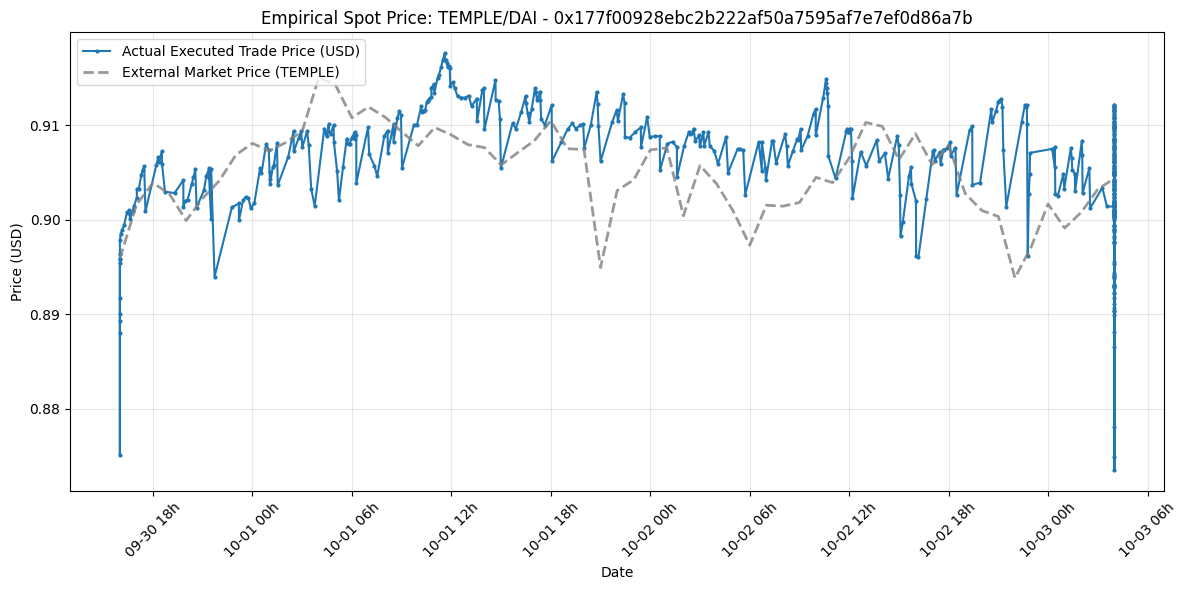


Processing EMPIRICAL Price for: TEMPLE (DAI LBP)...
   > Pool Address: 0x3e872e44a28b5bdaf52227f90ae25d0602fe06b8
   > Duration: ~2.0 days
   > Total Trades: 587 | Valid for Plot: 585
   > Saved chart to: rLBP_TEMPLE_DAI_0x3e87_2022-10-12.png


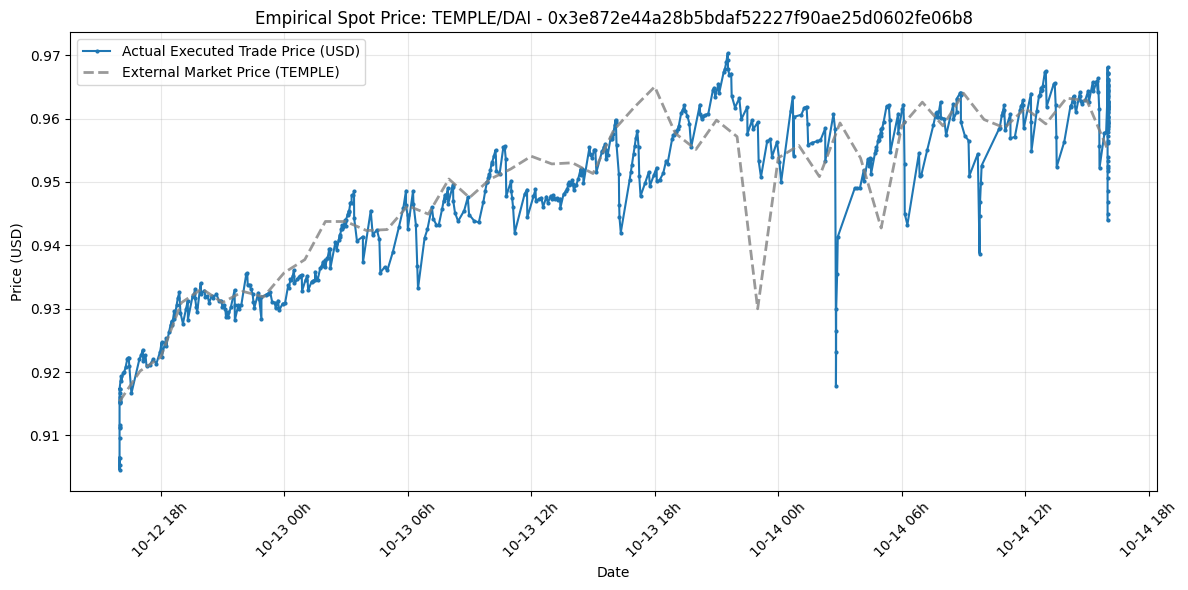


Processing EMPIRICAL Price for: TEMPLE (DAI LBP)...
   > Pool Address: 0x6f2528f9972c8fb70a9db8c3e26d537dc2ce8ef0
   > Duration: ~2.5 days
   > Total Trades: 283 | Valid for Plot: 283
   > Saved chart to: rLBP_TEMPLE_DAI_0x6f25_2022-09-06.png


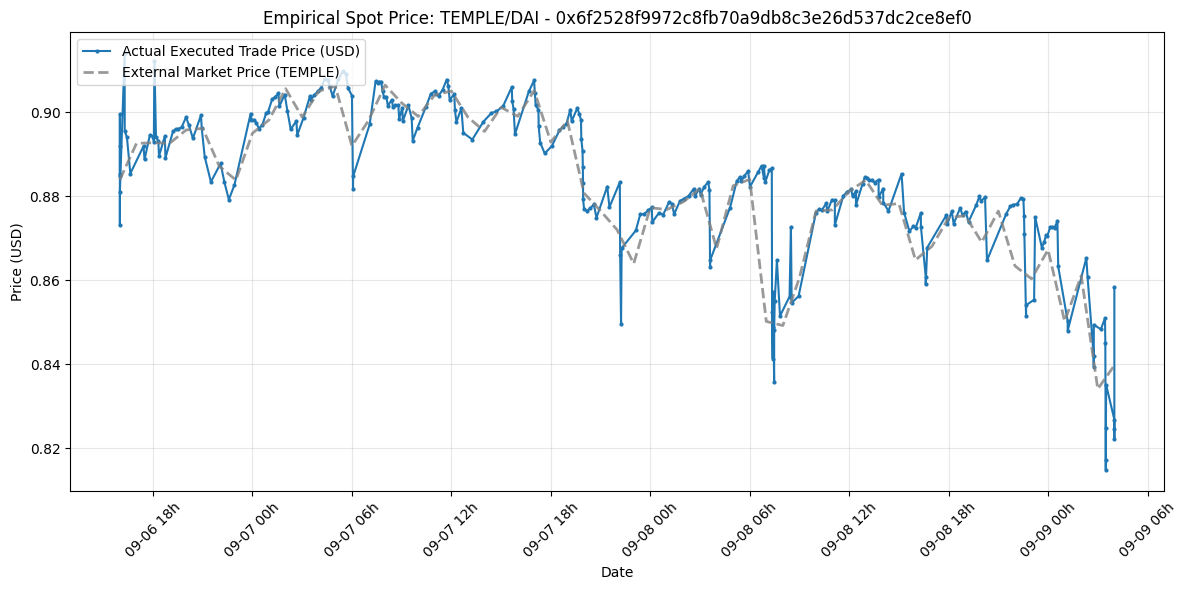


Processing EMPIRICAL Price for: TEMPLE (DAI LBP)...
   > Pool Address: 0x8de0508507492661f9e4ba99755e198cd1ad50a2
   > Duration: ~2.5 days
   > Total Trades: 461 | Valid for Plot: 461
   > Saved chart to: rLBP_TEMPLE_DAI_0x8de0_2022-10-05.png


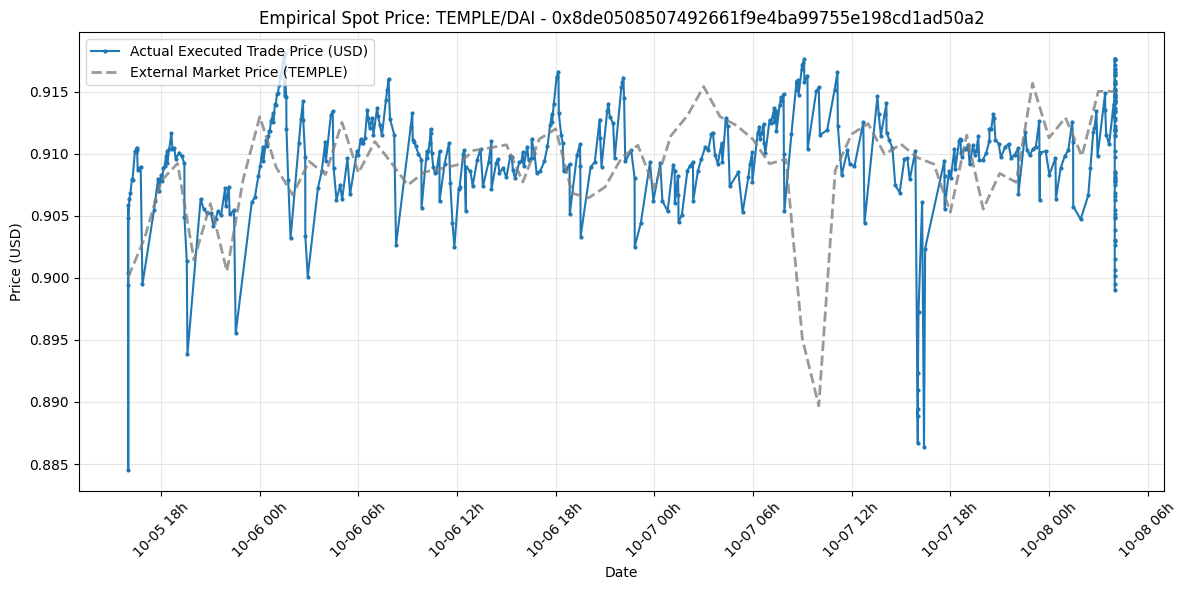


Processing EMPIRICAL Price for: TEMPLE (FRAX LBP)...
   > Pool Address: 0xa47dc2ec2960e6ab4442bf1838e35fdcf4fe724a
   > Duration: ~2.5 days
   > Total Trades: 467 | Valid for Plot: 467
   > Saved chart to: rLBP_TEMPLE_FRAX_0xa47d_2022-09-09.png


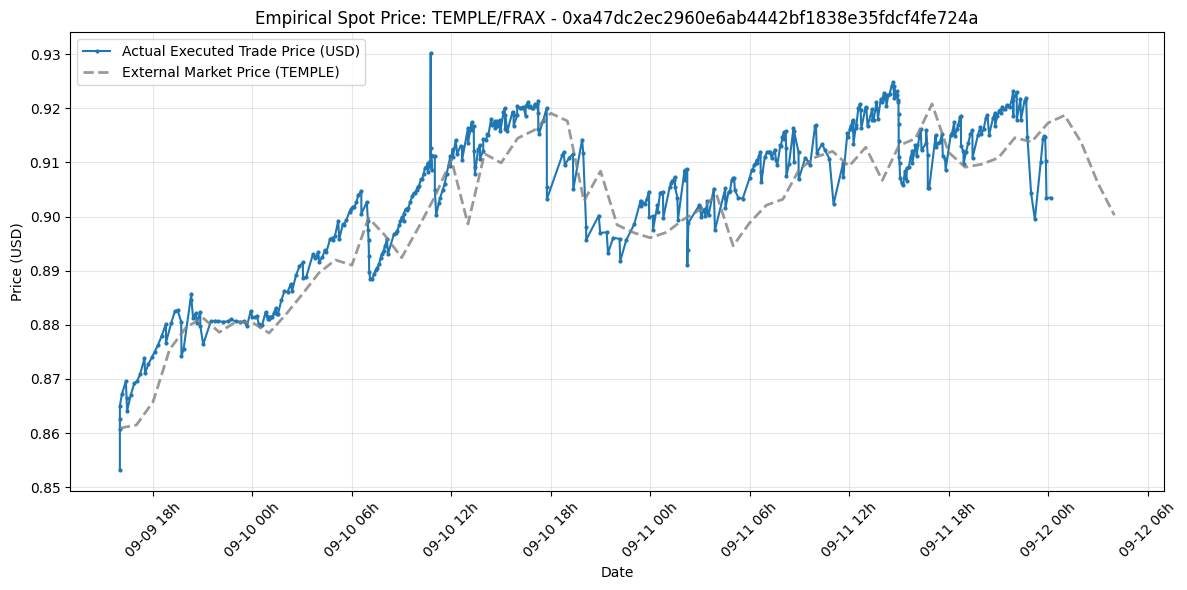


Processing EMPIRICAL Price for: TEMPLE (DAI LBP)...
   > Pool Address: 0xa49b4174283b82ac6489fdbff59bcd1b96794edf
   > Duration: ~1.2 days
   > Total Trades: 459 | Valid for Plot: 459
   > Saved chart to: rLBP_TEMPLE_DAI_0xa49b_2022-09-13.png


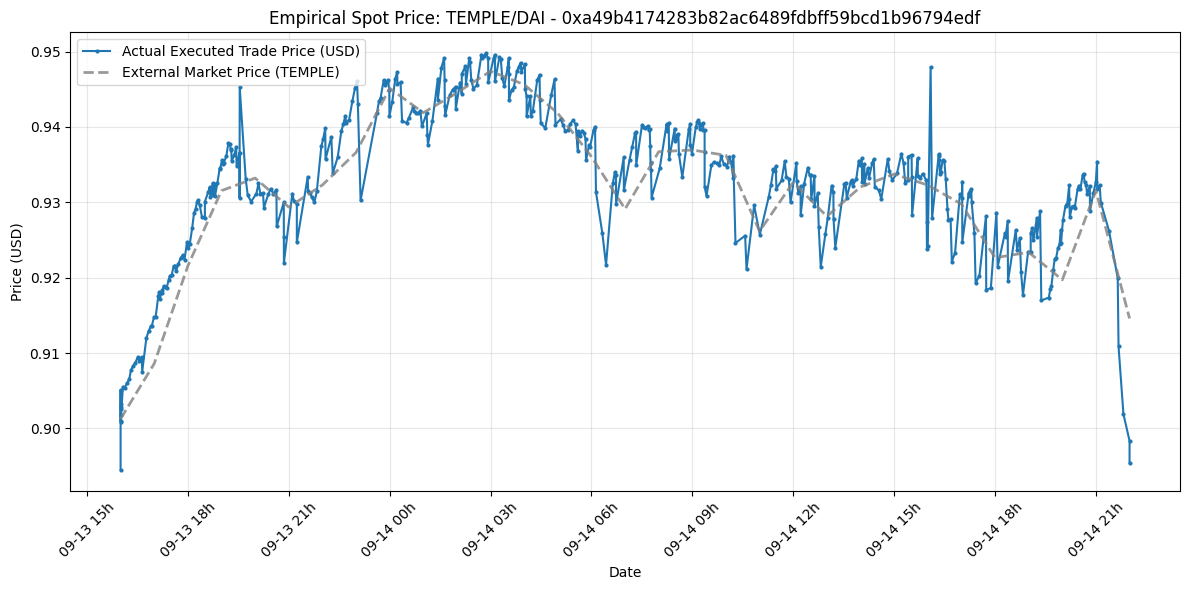


Processing EMPIRICAL Price for: TEMPLE (DAI LBP)...
   > Pool Address: 0xbaed9f622f88c1b3f79ca5f4bf57688580951fa3
   > Duration: ~3.8 days
   > Total Trades: 234 | Valid for Plot: 234
   > Saved chart to: rLBP_TEMPLE_DAI_0xbaed_2022-08-27.png


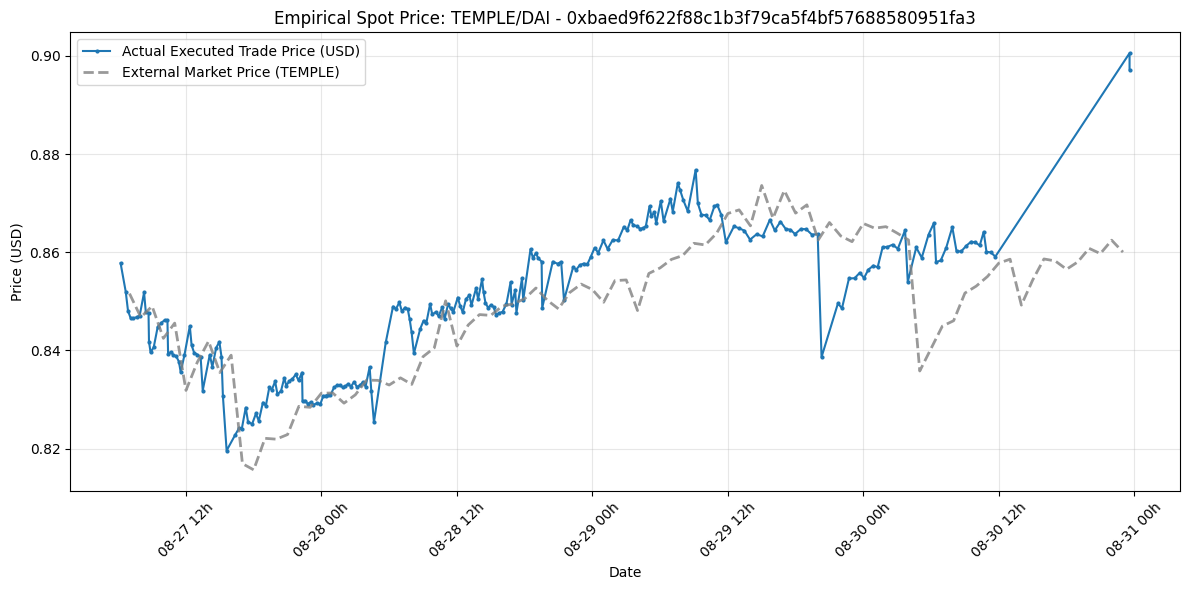


Processing EMPIRICAL Price for: TEMPLE (DAI LBP)...
   > Pool Address: 0xd328ffd19422585537a843e278490a8b21627216
   > Duration: ~1.2 days
   > Total Trades: 50 | Valid for Plot: 50
   > Saved chart to: rLBP_TEMPLE_DAI_0xd328_2022-08-20.png


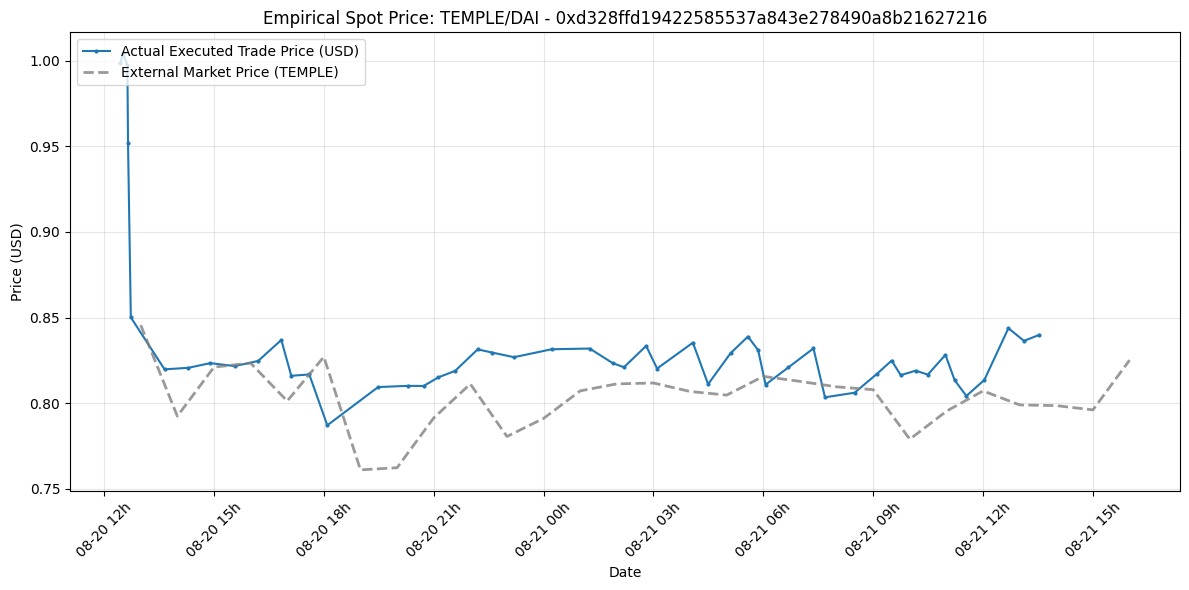


Processing EMPIRICAL Price for: TEMPLE (DAI LBP)...
   > Pool Address: 0xe11b6a3fa1e69ab2d9aa872701cfb32decec6d41
   > Duration: ~2.1 days
   > Total Trades: 84 | Valid for Plot: 84
   > Saved chart to: rLBP_TEMPLE_DAI_0xe11b_2022-08-24.png


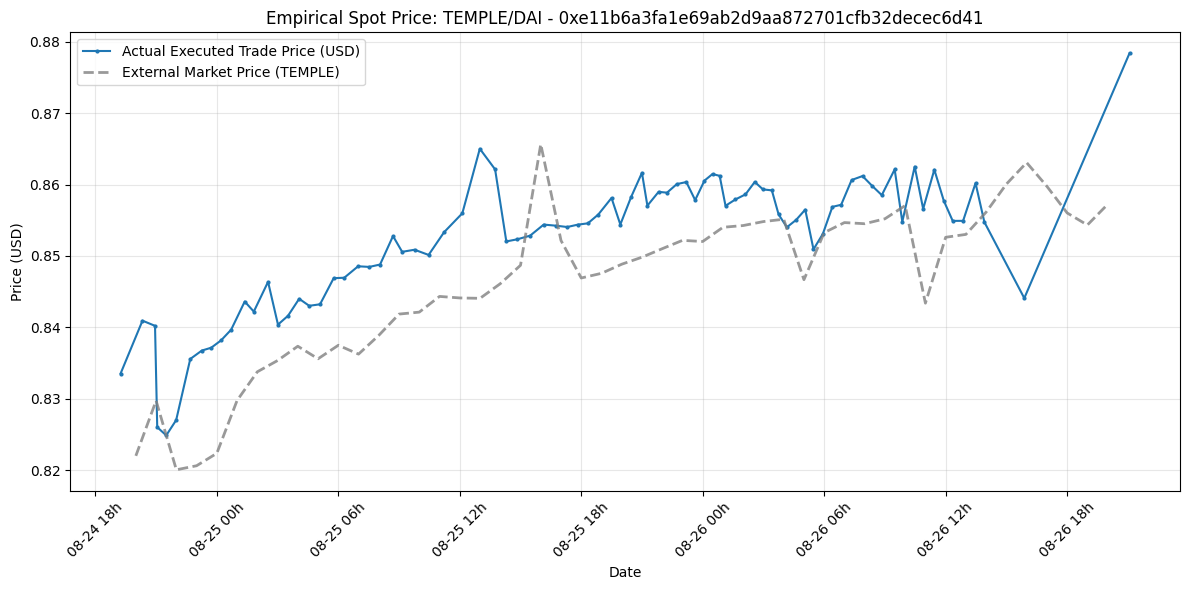


Processing EMPIRICAL Price for: TEMPLE (DAI LBP)...
   > Pool Address: 0xf812a0565b1d396c1518ff547d23f6dc27c53686
   > Duration: ~1.7 days
   > Total Trades: 53 | Valid for Plot: 53
   > Saved chart to: rLBP_TEMPLE_DAI_0xf812_2022-08-22.png


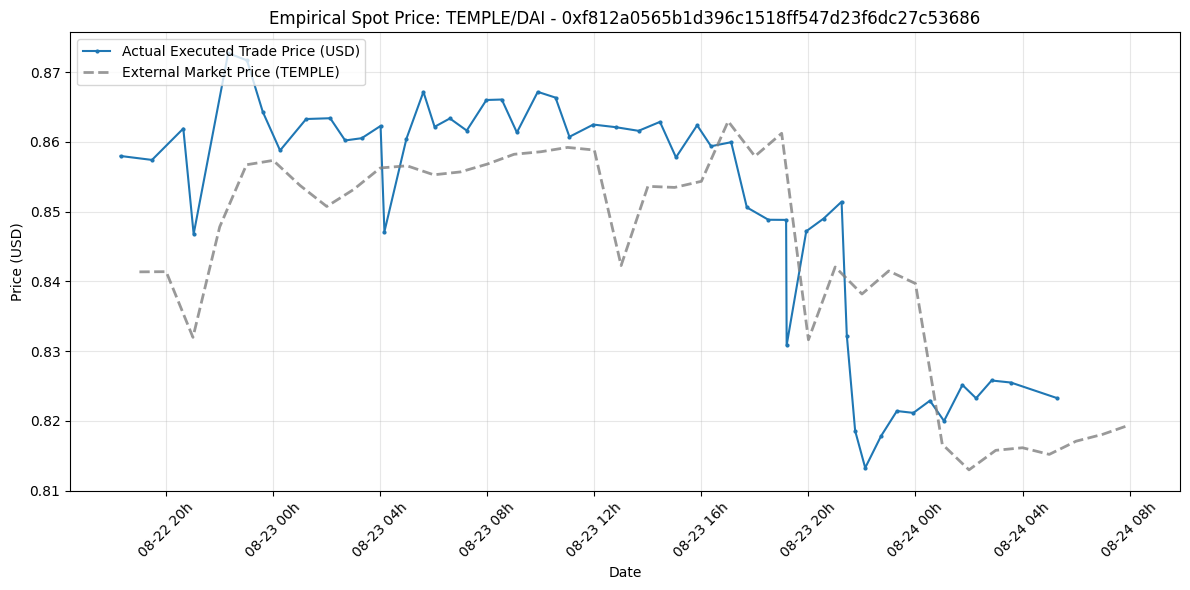


Processing EMPIRICAL Price for: TEMPLE (DAI LBP)...
   > Pool Address: 0xf88278315a1d5ace3aaa41712f60602e069208e6
   > Duration: ~2.5 days
   > Total Trades: 527 | Valid for Plot: 527
   > Saved chart to: rLBP_TEMPLE_DAI_0xf882_2022-09-22.png


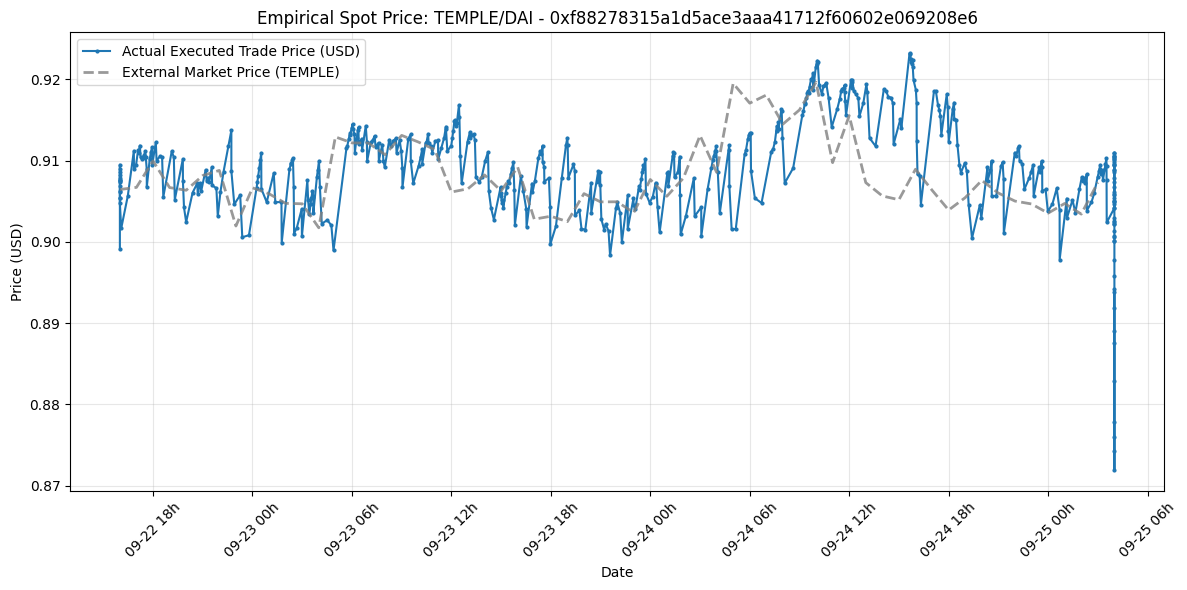

In [7]:
# ==========================================
# EMPIRICAL TRADE-BASED PRICE (NO LBP FORMULA)
# ==========================================

# 1. CONSTANTS & MAPPINGS
PROJECT_DECIMALS = {'ICHI': 9, 'IDLE': 18, 'TEMPLE': 18, 'REMIO': 18}
DECIMALS = {'WETH': 18, 'DAI': 18, 'USDC': 6}

df_market = pd.read_csv(V1V2_MARKET_FILE)
df_trades = pd.read_csv(V1V2_TRADES_FILE)

df_market['hour'] = pd.to_datetime(df_market['hour']).dt.tz_localize(None)
df_trades['poolId'] = df_trades['poolId'].str.lower()

# We dynamically map the pool to the market data
available_symbols = df_market['symbol'].dropna().unique()
POOL_SYMBOL_MAP = {}
unique_pools = df_trades[['poolId', 'pool_name']].drop_duplicates()
for _, row in unique_pools.iterrows():
    matched = 'UNKNOWN'
    for sym in available_symbols:
        if sym.lower() in str(row['pool_name']).lower():
            matched = sym
            break
    POOL_SYMBOL_MAP[row['poolId']] = matched

# 2. PROCESSING LOOP
for _, pool in df_pools.iterrows():
    pid = pool['poolId']
    proj_symbol = POOL_SYMBOL_MAP.get(pid, "UNKNOWN")
    
    print(f"\nProcessing EMPIRICAL Price for: {proj_symbol} ({pool['collateral_symbol']} LBP)...")

    # Filter and sort trades
    pool_trades = df_trades[df_trades['poolId'] == pid].copy().sort_values('block_number')
    if pool_trades.empty: continue
    
    # Get Decimals
    col_sym = pool['collateral_symbol']
    col_dec = DECIMALS.get(col_sym, 18)
    proj_dec = PROJECT_DECIMALS.get(proj_symbol, 18)
    proj_addr = pool['project_token_address'].lower().replace('0x', '')
    
    # Time data for interpolation
    t_start = pd.to_datetime(pool['start_date'])
    total_time = (pd.to_datetime(pool['end_date']) - t_start).total_seconds()
    
    # --- Calculate duration in days ---
    duration_days = total_time / (24 * 3600)
    # ---------------------------------------

    trade_prices = []
    
    # 3. CALCULATE PRICE FOR EVERY TRADE
    for _, trade in pool_trades.iterrows():
        # A. Calculate Timestamp
        block_prog = (trade['block_number'] - pool['start_block_approx']) / (pool['end_block_est'] - pool['start_block_approx'])
        block_prog = max(0, min(1, block_prog))
        curr_ts = t_start + timedelta(seconds=total_time * block_prog)
        
        # B. Decode Trade Amounts (Hex to Int)
        data = trade['data'].replace('0x', '')
        if len(data) < 128: continue
        amt0_raw = int(data[0:64], 16)
        amt1_raw = int(data[64:128], 16)
        
        # C. Identify Direction & Calculate Price
        topic1 = str(trade['topic1_token_in']).lower()
        
        if proj_addr in topic1:
            proj_amt = amt0_raw / (10**proj_dec) # Token In
            col_amt = amt1_raw / (10**col_dec)   # Token Out
        else:
            col_amt = amt0_raw / (10**col_dec)   # Token In
            proj_amt = amt1_raw / (10**proj_dec) # Token Out
            
        if proj_amt <= 0 or col_amt <= 0:
            continue
            
        native_price = col_amt / proj_amt
        
        # D. Convert to USD
        usd_price = native_price
        if col_sym == 'WETH' and eth_history is not None:
            try:
                day_key = curr_ts.replace(hour=0, minute=0, second=0, microsecond=0)
                eth_price = eth_history.loc[day_key]
                usd_price = native_price * eth_price
            except: pass 
            
        trade_prices.append({'date': curr_ts, 'price': usd_price})

    # ==========================================
    # 4. PLOTTING & SAVING
    # ==========================================
    if trade_prices:
        df_plot = pd.DataFrame(trade_prices)
        
        # --- PRINTS ---
        print(f"   > Pool Address: {pool['pool_address']}")
        print(f"   > Duration: ~{duration_days:.1f} days")
        print(f"   > Total Trades: {len(pool_trades)} | Valid for Plot: {len(df_plot)}")
        # ----------------------------

        plt.figure(figsize=(12, 6))
        
        plt.plot(df_plot['date'], df_plot['price'], label='Actual Executed Trade Price (USD)', color='#1f77b4', linewidth=1.5, marker='.', markersize=4)
        
        if proj_symbol != "UNKNOWN":
            mask = df_market['symbol'] == proj_symbol
            mask_date = (df_market['hour'] >= pool['start_date']) & (df_market['hour'] <= pool['end_date'])
            df_ext = df_market[mask & mask_date].sort_values('hour')
            
            if not df_ext.empty:
                plt.plot(df_ext['hour'], df_ext['market_price_avg'], 
                         label=f'External Market Price ({proj_symbol})', 
                         color='gray', linestyle='--', linewidth=2, alpha=0.8)
        
        plt.title(f"Empirical Spot Price: {proj_symbol}/{col_sym} - {pool['pool_address']}")
        plt.ylabel("Price (USD)")
        plt.xlabel("Date")
        plt.legend(loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %Hh'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        # --- NEW: SAVE IMAGE ---
        # Pattern: rLBP_{Project}_{Collateral}_{AddressPrefix}_{Date}
        # Example: rLBP_TEMPLE_DAI_0xacd7_2022-08-31.png
        addr_prefix = str(pool['pool_address'])[:6]
        date_str = t_start.strftime('%Y-%m-%d')
        filename = f"rLBP_{proj_symbol}_{col_sym}_{addr_prefix}_{date_str}.png"
        
        plt.savefig(filename)
        print(f"   > Saved chart to: {filename}")
        # -----------------------
        
        plt.show()

## Evaluate the rLBP success based on its theorical benefits

### Article listed benefits

Running Final Evaluation...

=== FINAL rLBP PERFORMANCE REPORT ===
       Pool  Bot_Score  Fair_Val  Stability  Cost_Eff  Final_GPA
 DAI-0xbaed      100.0      98.1       94.6         0       73.2
 DAI-0xf812      100.0      95.8       90.9         0       71.7
 DAI-0xa49b      100.0      97.9       87.5         0       71.3
 DAI-0xf882      100.0      94.6       81.7         0       69.1
 DAI-0xd328      100.0      97.2       75.8         0       68.2
FRAX-0xa47d      100.0      96.3       73.6         0       67.5
 DAI-0xe11b      100.0      92.3       71.3         0       65.9
 DAI-0x8de0      100.0      93.5       68.3         0       65.4
 DAI-0x177f      100.0      93.2       67.8         0       65.2
 DAI-0x174c      100.0      87.3       50.5         0       59.4
 DAI-0x6f25      100.0      81.1        0.0         0       45.3
 DAI-0x3e87      100.0       0.0        0.0         0       25.0
WETH-0x4693      100.0       0.0        0.0         0       25.0
WETH-0xa4a8      100.0 

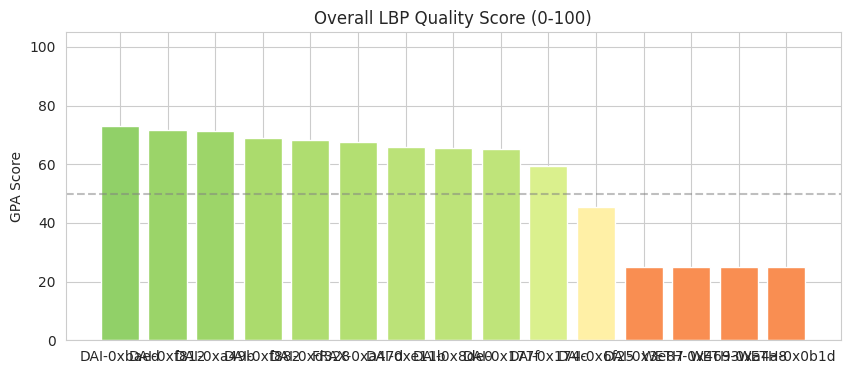

In [20]:
# ==========================================
# 1. METRIC CALCULATOR ENGINE
# ==========================================

def calculate_metrics(df_trades, pool_meta):
    """
    Calculates the 4 key metrics for a Reverse LBP.
    Expects df_trades to have: ['block_number', 'timestamp', 'exec_price', 'spot_price', 'amount_usd', 'side']
    """
    if df_trades.empty:
        return {k: 0 for k in ['Bot_Score', 'Fair_Val', 'Stability', 'Cost_Eff', 'Final_GPA']}

    # --- METRIC 1: BOT & DUMP RESISTANCE (Corrected) ---
    # Old Way: Penalized ALL volume (Bad for rLBP).
    # New Way: Penalize only SELL volume in the first 50 blocks (~10 mins).
    # --- METRIC 1: BOT & FRONTRUNNING RESISTANCE (Corrigido para rLBP) ---
    start_block = df_trades['block_number'].min()
    early_window = df_trades[df_trades['block_number'] <= start_block + 50]

    if not early_window.empty:
        # Penalizar COMPRAS iniciais (frontrunning), não vendas
        early_buy_vol = early_window[early_window['side'] == 'BUY']['amount_usd'].sum()
        total_vol = df_trades['amount_usd'].sum()
        
        sniper_ratio = (early_buy_vol / total_vol) if total_vol > 0 else 0
        bot_score = max(0, 100 - (sniper_ratio * 200))  # 50% sniper = 0
    else:
        bot_score = 100  # Sem atividade inicial = bom

    # --- METRIC 2: FAIR VALUE DISCOVERY ---
    # Compare LBP Close Price vs. Post-LBP Price (Stability check)
    # We take the average of the last 10 trades as "Close Price"
    close_price = df_trades.tail(10)['exec_price'].mean()
    
    # Ideally we'd look at future data, but using available data:
    # If the price trended UP and held, it's good. 
    # We penalize volatility in the second half.
    second_half = df_trades.iloc[len(df_trades)//2:]
    if not second_half.empty:
        price_dev = second_half['exec_price'].std() / second_half['exec_price'].mean()
        fair_val_score = max(0, 100 - (price_dev * 200)) # 50% deviation = 0 score
    else:
        fair_val_score = 50 # Neutral if no data

    # --- METRIC 3: MARKET STABILITY ---
    # Measures chaos/volatility per trade
    returns = df_trades['exec_price'].pct_change().dropna()
    volatility = returns.std()
    stability_score = max(0, 100 - (volatility * 1000))

    # --- METRIC 4: COST EFFICIENCY (Corrected) ---
    # Old Way: Compared to Market Price (Arbitrage).
    # New Way: Compare Exec Price vs. Spot Price (Slippage/Impact).
    # Formula: |(Exec - Spot) / Spot|
    
    # Filter out tiny dust trades that might have weird pricing
    valid_trades = df_trades[df_trades['amount_usd'] > 10] 
    
    if not valid_trades.empty:
        slippage = (valid_trades['exec_price'] - valid_trades['spot_price']).abs() / valid_trades['spot_price']
        avg_slippage = slippage.mean()
        
        # 5% average slippage = Score 0. 
        # 0.5% average slippage = Score 90.
        cost_score = max(0, 100 - (avg_slippage * 2000))
    else:
        cost_score = 100

    # --- FINAL GPA ---
    final_gpa = (bot_score * 0.25) + (fair_val_score * 0.25) + (stability_score * 0.25) + (cost_score * 0.25)
    
    return {
        'Bot_Score': round(bot_score, 1),
        'Fair_Val': round(fair_val_score, 1),
        'Stability': round(stability_score, 1),
        'Cost_Eff': round(cost_score, 1),
        'Final_GPA': round(final_gpa, 1)
    }

# ==========================================
# 2. DATA ENRICHMENT LOOP (Generates Spot Price)
# ==========================================
eval_results = []

print("Running Final Evaluation...")

for _, pool in df_pools.iterrows():
    pid = pool['poolId']
    
    # Filter Trades
    pool_trades = df_trades[df_trades['poolId'] == pid].copy()
    if pool_trades.empty: continue
    
    pool_trades = pool_trades.sort_values('block_number')
    
    # Initialize Replay for Spot Price Calculation
    curr_bal_col = pool['collateral_balance']
    curr_bal_proj = pool['project_balance']
    w_col_start = pool['collateral_start_weight'] / 100.0
    w_col_end = pool['collateral_end_weight'] / 100.0
    total_time = (pool['end_date'] - pool['start_date']).total_seconds()
    
    col_sym = pool['collateral_symbol']
    dec_col = DECIMALS.get(col_sym, 18)
    dec_proj = 18
    
    rich_data = []
    
    # --- REPLAY TO GENERATE METRICS DATA ---
    for _, trade in pool_trades.iterrows():
        # A. Calc Weights
        block_prog = (trade['block_number'] - pool['start_block_approx']) / (pool['end_block_est'] - pool['start_block_approx'])
        block_prog = max(0, min(1, block_prog))
        
        # B. Calc Spot Price (Pre-Trade)
        w_col = w_col_start + (w_col_end - w_col_start) * block_prog
        w_proj = 1.0 - w_col
        
        if curr_bal_proj > 0 and w_col > 0:
            spot_price_native = (curr_bal_col / w_col) / (curr_bal_proj / w_proj)
        else:
            spot_price_native = 0
            
        # USD Conversion
        eth_p = 2000 # Fallback
        if col_sym == 'WETH' and eth_history is not None:
            try:
                ts = pd.to_datetime(pool['start_date']) + timedelta(seconds=total_time*block_prog)
                day = ts.replace(hour=0, minute=0, second=0, microsecond=0)
                if day in eth_history.index: eth_p = eth_history.loc[day]
            except: pass
            spot_price_usd = spot_price_native * eth_p
        elif col_sym in ['DAI', 'USDC']:
            spot_price_usd = spot_price_native
        else:
            spot_price_usd = 0 # Skip weird pools
            
        # C. Parse Execution & Side
        try:
            data = trade['data'].replace('0x', '')
            amt0 = int(data[0:64], 16)
            amt1 = int(data[64:128], 16)
            
            # Identify Side - CORRIGIDO
            topic1 = str(trade['topic1_token_in']).lower()
            proj_addr_clean = pool['project_token_address'].lower()

            if proj_addr_clean in topic1:
                # BUY = Project token IN (Buyback)
                side = 'BUY'
                curr_bal_proj += amt0 / (10**dec_proj)
                curr_bal_col -= amt1 / (10**dec_col)
                
                amount_usd = (amt1 / (10**dec_col)) * (eth_p if col_sym=='WETH' else 1.0)
                
                if amt0 > 0:
                    exec_price_usd = amount_usd / (amt0 / 10**dec_proj)
                else:
                    exec_price_usd = spot_price_usd
            else:
                # SELL = Collateral IN (protocolo vendendo)
                side = 'SELL'
                curr_bal_col += amt0 / (10**dec_col)
                curr_bal_proj -= amt1 / (10**dec_proj)
                
                amount_usd = (amt0 / (10**dec_col)) * (eth_p if col_sym=='WETH' else 1.0)
                
                if amt1 > 0:
                    exec_price_usd = amount_usd / (amt1 / 10**dec_proj)
                else:
                    exec_price_usd = spot_price_usd

            rich_data.append({
                'block_number': trade['block_number'],
                'timestamp': trade['block_number'], # Proxy
                'spot_price': spot_price_usd,
                'exec_price': exec_price_usd,
                'amount_usd': amount_usd,
                'side': side
            })
            
        except:
            continue

    # --- CALCULATE SCORES ---
    df_rich = pd.DataFrame(rich_data)
    scores = calculate_metrics(df_rich, pool)
    
    # Add Identity
    scores['Pool'] = f"{pool['collateral_symbol']}-{pool['pool_address'][:6]}"
    eval_results.append(scores)

# ==========================================
# 3. DISPLAY RESULTS
# ==========================================
results_df = pd.DataFrame(eval_results)
if not results_df.empty:
    # Reorder columns
    cols = ['Pool', 'Bot_Score', 'Fair_Val', 'Stability', 'Cost_Eff', 'Final_GPA']
    results_df = results_df[cols].sort_values('Final_GPA', ascending=False)
    
    print("\n=== FINAL rLBP PERFORMANCE REPORT ===")
    print(results_df.to_string(index=False))
    
    # Optional: Plot GPA
    plt.figure(figsize=(10, 4))
    plt.bar(results_df['Pool'], results_df['Final_GPA'], color=plt.cm.RdYlGn(results_df['Final_GPA'] / 100))
    plt.title("Overall LBP Quality Score (0-100)")
    plt.ylabel("GPA Score")
    plt.axhline(50, color='gray', linestyle='--', alpha=0.5)
    plt.ylim(0, 105)
    plt.show()
else:
    print("No data to evaluate.")

### Personalized metrics

--- STARTING BUYBACK EFFICIENCY ANALYSIS (EMPIRICAL) ---

 > Generating automatic symbol mapping...
   Mapping complete: 16 pools identified.


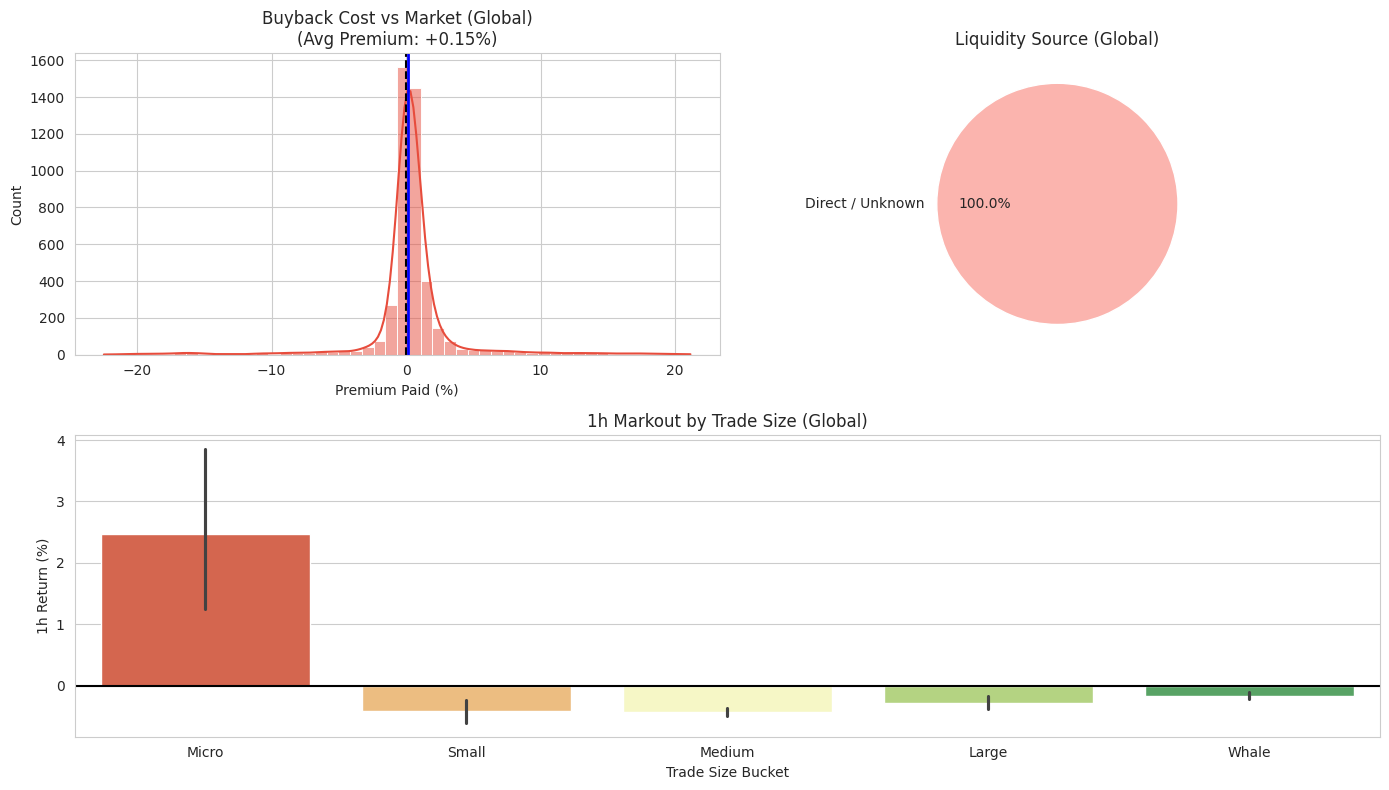


             INDIVIDUAL rLBP EFFICIENCY KPIs (TABLE)             
 Trade_Count Total_Volume Avg_Premium Avg_Markout
symbol    
TEMPLE 3870 $43,192,510.06 +0.13% -0.12%
ICHI 83 $509,106.94 +1.59% -1.94%
IDLE 556 $106,671.67 +2.38% +1.66%

--------------------------------------------------------------------------------

                   GLOBAL SAMPLE SUMMARY                   
Total Analyzed Volume:    $43,808,288.67
--------------------------------------------------------------------------------
1. GLOBAL EXECUTION COST (Premium vs Market)
   Weighted Average:      +0.15%
   >> The Pool paid 0.15% ABOVE market price (Cost).

2. GLOBAL INVENTORY EFFICIENCY (1h Markout)
   Return after 1h:       -0.13%


In [8]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
KNOWN_ROUTERS = {
    '0x1111111254fb6c44baca0b5c94751821156db930': '1inch v4',
    '0x11111112542d85b3ef69ae05771c2dccff4faa26': '1inch v5',
    '0x9008d19f58aabd9332f9815c77c8b8cf84258491': 'CoW Protocol',
    '0xdef171fe48cf0115b1d80b88dc8eab59176fee57': 'ParaSwap',
    '0x68b3465833fb72a70ecdf485e0e4c7bd8665fc45': 'Uniswap V3',
    '0x7a250d5630b4cf539739df2c5dacb4c659f2488d': 'Uniswap V2',
    '0x881d40237659c251811cec9c364ef91dc08d300c': 'Metamask Swap',
}

KNOWN_MEV_BOTS = {
    '0xae2fc483527b8ef99eb5d9b44875f005ba1fae13': 'JaredFromSubway',
    '0x6b75d8af000000e20b7a7ddf000ba900b4009a80': 'MEV Bot A',
}

# --- CRITICAL FIX: DECIMALS MAP ---
PROJECT_DECIMALS = {
    'ICHI': 9,
    'IDLE': 18,
    'TEMPLE': 18,
    'REMIO': 18
}

DECIMALS = {'WETH': 18, 'DAI': 18, 'USDC': 6}

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def decode_swap_data(hex_str):
    clean = hex_str.replace('0x', '')
    if len(clean) < 128: return 0, 0
    return int(clean[0:64], 16), int(clean[64:128], 16)

def classify_source(sender_address):
    addr = str(sender_address).lower().replace('0x000000000000000000000000', '0x')
    if addr in KNOWN_ROUTERS: return 'Aggregator (Organic)'
    elif addr in KNOWN_MEV_BOTS: return 'MEV Bot (Arbitrage)'
    else: return 'Direct / Unknown'


print("--- STARTING BUYBACK EFFICIENCY ANALYSIS (EMPIRICAL) ---\n")

# 1. LOAD DATA
try:
    df_trades = pd.read_csv(V1V2_TRADES_FILE)
    df_market = pd.read_csv(V1V2_MARKET_FILE)
    df_meta = pd.read_csv(V1V2_POOLS_FILE)
    try:
        df_temple = pd.read_csv('rLBPs_BalancerV2_TEMPLE_market_value_2022.csv')
        df_temple['symbol'] = 'TEMPLE'
        df_temple = df_temple[['hour', 'market_price_avg', 'symbol']]
        df_market = pd.concat([df_market, df_temple], ignore_index=True)
    except: pass
except FileNotFoundError:
    print("Error: Files not found.")
    raise

# 2. PREPARE MARKET DATA
df_market['hour'] = pd.to_datetime(df_market['hour']).dt.tz_localize(None)
df_market = df_market.drop_duplicates(subset=['hour', 'symbol']).sort_values('hour')

market_lookups = {}
for sym, group in df_market.groupby('symbol'):
    market_lookups[sym] = group.set_index('hour')['market_price_avg']

# ==========================================
# AUTOMATIC SYMBOL MAPPING
# ==========================================
print(" > Generating automatic symbol mapping...")
available_symbols = df_market['symbol'].dropna().unique()
POOL_SYMBOL_MAP = {}
df_trades['poolId'] = df_trades['poolId'].str.lower()
unique_pools = df_trades[['poolId', 'pool_name']].drop_duplicates()

for _, row in unique_pools.iterrows():
    p_id = row['poolId']
    p_name = str(row['pool_name']).lower()
    matched_symbol = 'UNKNOWN'
    for sym in available_symbols:
        if sym.lower() in p_name:
            matched_symbol = sym
            break
    POOL_SYMBOL_MAP[p_id] = matched_symbol

# --- MANUAL OVERRIDE FOR REMIO (If market data is missing) ---
POOL_SYMBOL_MAP['0xa35bd2246978dfbb1980dff8ff0f5834335dfdbc'] = 'REMIO'

print(f"   Mapping complete: {len(POOL_SYMBOL_MAP)} pools identified.")

# --- FETCH ETH HISTORY FOR USD CONVERSION ---
if 'eth_history' not in globals() or eth_history is None:
    print(" ! Fetching ETH History for USD conversion...")
    eth_history = fetch_usd_history_robust('WETH', pd.to_datetime("2020-01-01"), pd.to_datetime("2023-01-01"))

# 3. PROCESS TRADES
buyback_trades = []
for _, pool in df_meta.iterrows():
    pid = pool['poolId']
    proj_addr = pool['project_token_address'].lower()
    col_symbol = pool['collateral_symbol']
    col_dec = DECIMALS.get(col_symbol, 18)
    
    proj_symbol = POOL_SYMBOL_MAP.get(pool['pool_address'], POOL_SYMBOL_MAP.get(pool['poolId'], 'UNKNOWN'))
    proj_dec = PROJECT_DECIMALS.get(proj_symbol, 18)
    
    pool_trades = df_trades[df_trades['poolId'] == pid].copy().sort_values('block_number')
    t_start = pd.to_datetime(pool['start_date'])
    duration = (pd.to_datetime(pool['end_date']) - t_start).total_seconds()
    pool_trades['progress'] = (pool_trades['block_number'] - pool['start_block_approx']) / \
                              (pool['end_block_est'] - pool['start_block_approx'])
    pool_trades['timestamp'] = t_start + (pool_trades['progress'] * timedelta(seconds=duration))
    
    for idx, row in pool_trades.iterrows():
        amt_in, amt_out = decode_swap_data(row['data'])
        token_in = '0x' + str(row['topic1_token_in']).replace('0x', '')[-40:].lower()
        
        # IF BUYBACK (Token In == Project)
        if token_in == proj_addr:
            vol_proj = amt_in / (10**proj_dec)        
            vol_col = amt_out / (10**col_dec)
            
            if vol_proj > 0:
                exec_price_native = vol_col / vol_proj 
                
                eth_price = 1.0
                if col_symbol == 'WETH' and eth_history is not None:
                    try:
                        ts_lookup = row['timestamp'].replace(hour=0, minute=0, second=0, microsecond=0)
                        eth_price = eth_history.loc[ts_lookup]
                    except: eth_price = 2000.0
                
                price_paid_usd = exec_price_native * eth_price
                volume_usd = vol_col * eth_price

                buyback_trades.append({
                    'timestamp': row['timestamp'],
                    'volume_usd': volume_usd,
                    'price_paid': price_paid_usd,
                    'symbol': proj_symbol,
                    'sender': '0x' + str(row['topic1_token_in']).replace('0x', '')[-40:].lower()
                })

df = pd.DataFrame(buyback_trades)
if df.empty:
    print("No Buyback trades found.")
    raise

# 4. METRICS & VISUALIZATION
analysis_data = []

for idx, row in df.iterrows():
    sym = row['symbol']
    lookup = market_lookups.get(sym)
    if lookup is None: continue
    
    try:
        idx_now = lookup.index.get_indexer([row['timestamp']], method='nearest')[0]
        if idx_now == -1: continue
        price_mkt = lookup.iloc[idx_now]
        
        if row['price_paid'] <= 0 or price_mkt <= 0:
            continue
        
        premium_pct = (row['price_paid'] - price_mkt) / price_mkt * 100
        
        t_fut = row['timestamp'] + timedelta(hours=1)
        idx_fut = lookup.index.get_indexer([t_fut], method='nearest')[0]
        price_fut = lookup.iloc[idx_fut]
        markout_pct = (price_fut - row['price_paid']) / row['price_paid'] * 100
        
        analysis_data.append({
            'symbol': sym, # <-- NEW: Used for individual pool grouping
            'volume': row['volume_usd'],
            'premium_pct': premium_pct,
            'markout_1h': markout_pct,
            'source': classify_source(row['sender'])
        })
        
    except: pass
    
df_res = pd.DataFrame(analysis_data)
if df_res.empty:
    print("analysis_data is empty")
    raise

# Global Weighted Averages
total_vol = df_res['volume'].sum()
avg_premium = (df_res['premium_pct'] * df_res['volume']).sum() / total_vol
avg_markout = (df_res['markout_1h'] * df_res['volume']).sum() / total_vol
source_vol = df_res.groupby('source')['volume'].sum()

# Plotting (Global)
sns.set_style("whitegrid")
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
p_low, p_high = np.percentile(df_res['premium_pct'], [1, 99])
df_plot = df_res[(df_res['premium_pct'] > p_low) & (df_res['premium_pct'] < p_high)]

sns.histplot(df_plot['premium_pct'], bins=50, kde=True, ax=ax1, color='#e74c3c')
ax1.axvline(0, color='black', linestyle='--')
ax1.axvline(avg_premium, color='blue', linestyle='-', linewidth=2)
ax1.set_title(f"Buyback Cost vs Market (Global)\n(Avg Premium: {avg_premium:+.2f}%)")
ax1.set_xlabel("Premium Paid (%)")

ax2 = fig.add_subplot(gs[0, 1])
if not source_vol.empty:
    source_vol.plot.pie(autopct='%1.1f%%', ax=ax2, cmap='Pastel1', ylabel='')
    ax2.set_title("Liquidity Source (Global)")

ax3 = fig.add_subplot(gs[1, :])
# Rename labels for English Plot
df_res['size_bucket'] = pd.qcut(df_res['volume'], 5, labels=["Micro", "Small", "Medium", "Large", "Whale"])
sns.barplot(x='size_bucket', y='markout_1h', hue='size_bucket', data=df_res, ax=ax3, palette="RdYlGn", legend=False)
ax3.axhline(0, color='black')
ax3.set_title("1h Markout by Trade Size (Global)")
ax3.set_ylabel("1h Return (%)")
ax3.set_xlabel("Trade Size Bucket")

plt.tight_layout()
plt.show()

# ==========================================
# 5. INDIVIDUAL rLBP KPIs TABLE
# ==========================================
print("\n" + "="*80)
print("             INDIVIDUAL rLBP EFFICIENCY KPIs (TABLE)             ")
print("="*80)

# Calculate numerator for weighted averages
df_res['premium_weighted'] = df_res['premium_pct'] * df_res['volume']
df_res['markout_weighted'] = df_res['markout_1h'] * df_res['volume']

# Group by individual Symbol/Pool
summary = df_res.groupby('symbol').agg(
    Trade_Count=('volume', 'count'),
    Total_Volume=('volume', 'sum'),
    Sum_Premium_W=('premium_weighted', 'sum'),
    Sum_Markout_W=('markout_weighted', 'sum')
)

# Calculate final percentages
summary['Avg_Premium'] = summary['Sum_Premium_W'] / summary['Total_Volume']
summary['Avg_Markout'] = summary['Sum_Markout_W'] / summary['Total_Volume']

# Clean up and Format the table
final_table = summary[['Trade_Count', 'Total_Volume', 'Avg_Premium', 'Avg_Markout']].copy()
final_table = final_table.sort_values('Total_Volume', ascending=False)

# Pretty Print Format
format_dict = {
    'Total_Volume': '${:,.2f}',
    'Avg_Premium': '{:+.2f}%',
    'Avg_Markout': '{:+.2f}%'
}

print(final_table.style.format(format_dict).to_string())
print("-" * 80)

# ==========================================
# 6. GLOBAL TEXT REPORT
# ==========================================
print("\n" + "="*80)
print("                   GLOBAL SAMPLE SUMMARY                   ")
print("="*80)
print(f"Total Analyzed Volume:    ${total_vol:,.2f}")
print("-" * 80)
print("1. GLOBAL EXECUTION COST (Premium vs Market)")
print(f"   Weighted Average:      {avg_premium:+.2f}%")
if avg_premium > 0:
    print(f"   >> The Pool paid {avg_premium:.2f}% ABOVE market price (Cost).")
else:
    print(f"   >> The Pool paid {abs(avg_premium):.2f}% BELOW market price (Savings).")

print("\n2. GLOBAL INVENTORY EFFICIENCY (1h Markout)")
print(f"   Return after 1h:       {avg_markout:+.2f}%")
print("="*80)